In [1]:
%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

In [5]:
RANDOM_STATE = 42
USE_GPU = True
N_COMPONENTS = 20

In [6]:
# ---- 0. Paths ----
DATA_DIR = r"E:\NSU\cse445\EDA attempt3\Dataset\ML dataset"
TRAIN_FILE = f"{DATA_DIR}/ML_train.csv"
TEST_FILE = f"{DATA_DIR}/ML_test.csv"
BERT_FILE = r"E:\NSU\cse445\EDA attempt3\NLP models\embeddings\bert_embeddings.csv"

In [7]:
BEST_PARAMS = {
    "colsample_bytree": 0.9512165066659852,
    "learning_rate": 0.07643904937766527,
    "max_depth": 6,
    "min_child_weight": 7,
    "n_estimators": 459,
    "reg_alpha": 0.0014729254229045347,
    "reg_lambda": 0.845771345696438,
    "subsample": 0.8060762192885254,
}

In [8]:
TARGET_LOG = "log_target"
DROP_FROM_X = ["id", "target_usd", "log_target", "goal_usd"]

In [9]:
# ---- 1. Load data + PCA ----
train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)
bert_raw = pd.read_csv(BERT_FILE)

In [10]:
train_ids = set(train_df["id"])
feature_cols = [c for c in bert_raw.columns if c != "id"]
train_mask = bert_raw["id"].isin(train_ids)

In [11]:
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
pca.fit(bert_raw.loc[train_mask, feature_cols])
reduced_all = pca.transform(bert_raw[feature_cols])
reduced_cols = [f"bert_pca_{i}" for i in range(N_COMPONENTS)]
reduced_df = pd.DataFrame(reduced_all, columns=reduced_cols)
reduced_df.insert(0, "id", bert_raw["id"].values)

In [12]:
merged_train = train_df.merge(reduced_df, on="id", how="left")
merged_test = test_df.merge(reduced_df, on="id", how="left")

In [13]:
X_full = merged_train.drop(columns=DROP_FROM_X, errors="ignore")
y_full = merged_train[TARGET_LOG].copy()

In [14]:
# ---- 2. Split train into train/validation (validation used only for curve, not test set) ----
X_tr, X_val, y_tr, y_val = train_test_split(
    X_full, y_full, test_size=0.15, random_state=RANDOM_STATE
)

In [15]:
print(f"Train: {X_tr.shape}, Val: {X_val.shape}")

Train: (13600, 97), Val: (2400, 97)


In [16]:
# ---- 3. Fit with eval_set to track train/val RMSE per boosting round ----
model = XGBRegressor(
    objective="reg:squarederror", eval_metric="rmse",
    tree_method="hist", device="cuda" if USE_GPU else "cpu",
    random_state=RANDOM_STATE,
    **BEST_PARAMS,
)

In [17]:
model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=False,
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9512165066659852
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'rmse'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [18]:
results = model.evals_result()
train_rmse = results["validation_0"]["rmse"]
val_rmse = results["validation_1"]["rmse"]
iterations = range(1, len(train_rmse) + 1)

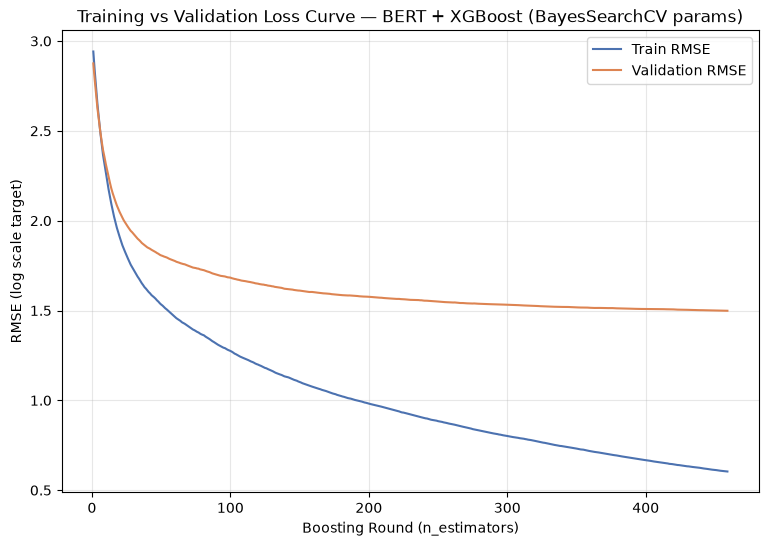

In [ ]:
# ---- 4. Plot loss curve ----
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(iterations, train_rmse, label="Train RMSE", color="#4C72B0")
ax.plot(iterations, val_rmse, label="Validation RMSE", color="#DD8452")
ax.set_xlabel("Boosting Round (n_estimators)")
ax.set_ylabel("RMSE (log scale target)")
# ax.set_title("Training vs Validation Loss Curve — BERT + XGBoost (BayesSearchCV params)")
ax.legend()
ax.grid(True, alpha=0.3)

In [20]:
best_round = int(np.argmin(val_rmse)) + 1
ax.axvline(best_round, color="green", linestyle="--", alpha=0.6,
           label=f"Best val round = {best_round}")
ax.legend()

In [21]:
plt.tight_layout()
plt.savefig("bert_xgb_loss_curve.png", dpi=150)
plt.show()

<Figure size 640x480 with 0 Axes>

In [22]:
print(f"\nMin validation RMSE: {min(val_rmse):.4f} at round {best_round}")
print(f"n_estimators used: {BEST_PARAMS['n_estimators']}")
print("Saved: bert_xgb_loss_curve.png")


Min validation RMSE: 1.4986 at round 458
n_estimators used: 459
Saved: bert_xgb_loss_curve.png


In [23]:
pd.DataFrame({
    "Round": list(iterations),
    "Train_RMSE": train_rmse,
    "Val_RMSE": val_rmse,
}).to_csv("bert_xgb_loss_curve_data.csv", index=False)
print("Saved: bert_xgb_loss_curve_data.csv")

Saved: bert_xgb_loss_curve_data.csv
